In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("student_spending .csv")

In [5]:
df.head()

,Unnamed: 0,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method
0,0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,188,41,78,134,127,72,Credit/Debit Card
1,1,24,Female,Junior,Economics,1006,875,4908,557,365,85,252,74,92,226,129,68,Credit/Debit Card
2,2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,99,130,23,239,112,133,Cash
3,3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,223,99,30,163,105,55,Mobile Payment App
4,4,20,Female,Senior,Computer Science,810,522,3887,825,372,168,194,48,71,88,71,104,Credit/Debit Card


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                1000 non-null   int64 
 1   age                       1000 non-null   int64 
 2   gender                    1000 non-null   object
 3   year_in_school            1000 non-null   object
 4   major                     1000 non-null   object
 5   monthly_income            1000 non-null   int64 
 6   financial_aid             1000 non-null   int64 
 7   tuition                   1000 non-null   int64 
 8   housing                   1000 non-null   int64 
 9   food                      1000 non-null   int64 
 10  transportation            1000 non-null   int64 
 11  books_supplies            1000 non-null   int64 
 12  entertainment             1000 non-null   int64 
 13  personal_care             1000 non-null   int64 
 14  technology               

In [9]:
df.isnull().sum()

Unnamed: 0                  0
age                         0
gender                      0
year_in_school              0
major                       0
monthly_income              0
financial_aid               0
tuition                     0
housing                     0
food                        0
transportation              0
books_supplies              0
entertainment               0
personal_care               0
technology                  0
health_wellness             0
miscellaneous               0
preferred_payment_method    0
dtype: int64

In [12]:
# Check for and remove duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]
print(f"\nNumber of duplicate rows removed: {duplicates_removed}")


Number of duplicate rows removed: 0


In [15]:
df.groupby('year_in_school')['tuition'].describe()

,count,mean,std,min,25%,50%,75%,max
year_in_school,,,,,,,,
Freshman,253.0,4506.462451,829.252410,3012.0,3784.0,4511.0,5194.00,5998.0
Junior,247.0,4587.376518,898.073000,3007.0,3820.0,4650.0,5398.00,6000.0
Senior,254.0,4456.968504,873.687216,3003.0,3695.0,4441.5,5245.50,5976.0
Sophomore,246.0,4532.959350,840.197386,3004.0,3830.0,4588.5,5237.75,5997.0


In [22]:
x= df.groupby('year_in_school')['preferred_payment_method'].max()
print(x)
y= df.groupby('gender')['preferred_payment_method'].max()
print(y)

year_in_school
Freshman     Mobile Payment App
Junior       Mobile Payment App
Senior       Mobile Payment App
Sophomore    Mobile Payment App
Name: preferred_payment_method, dtype: object
gender
Female        Mobile Payment App
Male          Mobile Payment App
Non-binary    Mobile Payment App
Name: preferred_payment_method, dtype: object


In [23]:
 df.groupby('gender')['preferred_payment_method'].count()

gender
Female        323
Male          356
Non-binary    321
Name: preferred_payment_method, dtype: int64

In [26]:
print(df['monthly_income'].mean())
print(df.groupby('gender')['monthly_income'].mean())

1020.65
gender
Female        1024.328173
Male          1008.258427
Non-binary    1030.691589
Name: monthly_income, dtype: float64


In [30]:
df.groupby(['gender','major']).size()

gender      major           
Female      Biology             68
            Computer Science    67
            Economics           56
            Engineering         68
            Psychology          64
Male        Biology             77
            Computer Science    68
            Economics           77
            Engineering         71
            Psychology          63
Non-binary  Biology             83
            Computer Science    57
            Economics           71
            Engineering         53
            Psychology          57
dtype: int64

In [31]:
df.groupby(['gender','preferred_payment_method']).size()

gender      preferred_payment_method
Female      Cash                         97
            Credit/Debit Card           106
            Mobile Payment App          120
Male        Cash                        111
            Credit/Debit Card           120
            Mobile Payment App          125
Non-binary  Cash                        102
            Credit/Debit Card           114
            Mobile Payment App          105
dtype: int64

In [32]:
print(df.groupby('financial_aid')['monthly_income'].mean())

financial_aid
0        805.0
1       1296.0
2        722.0
3       1426.0
4        843.0
         ...  
993     1456.0
995      860.5
996     1329.0
998     1457.0
1000    1467.5
Name: monthly_income, Length: 627, dtype: float64


In [33]:
print(df['gender'].value_counts())

gender
Male          356
Female        323
Non-binary    321
Name: count, dtype: int64


In [34]:
print(df['major'].value_counts())

major
Biology             228
Economics           204
Computer Science    192
Engineering         192
Psychology          184
Name: count, dtype: int64


In [36]:
print(df['year_in_school'].value_counts())

year_in_school
Senior       254
Freshman     253
Junior       247
Sophomore    246
Name: count, dtype: int64


In [37]:
print(df['preferred_payment_method'].value_counts())

preferred_payment_method
Mobile Payment App    350
Credit/Debit Card     340
Cash                  310
Name: count, dtype: int64


In [40]:
print(df.groupby('age')['gender'].describe())

    count unique         top freq
age                              
18    124      3  Non-binary   45
19    108      3        Male   41
20    111      3      Female   41
21    118      3        Male   44
22    130      3        Male   49
23    128      3  Non-binary   46
24    136      3  Non-binary   50
25    145      3        Male   56


In [41]:
print(df.groupby('major')['gender'].describe())

                 count unique         top freq
major                                         
Biology            228      3  Non-binary   83
Computer Science   192      3        Male   68
Economics          204      3        Male   77
Engineering        192      3        Male   71
Psychology         184      3      Female   64


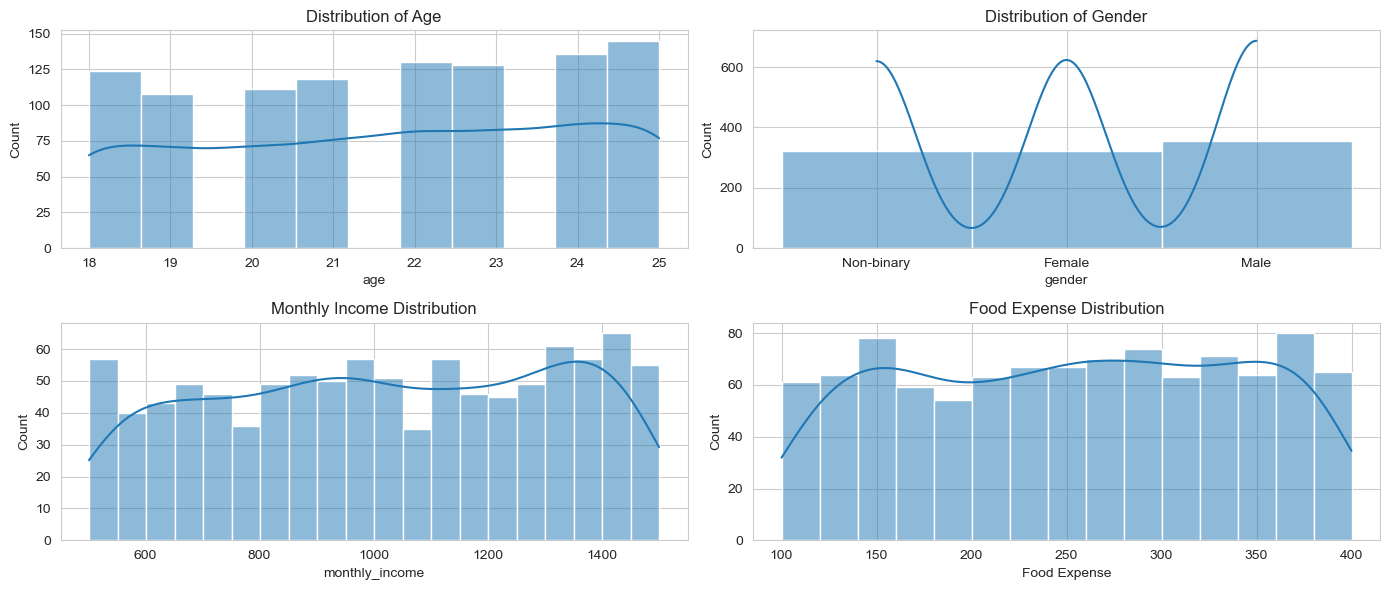

In [50]:
# Set style for plots
sns.set_style('whitegrid')

# Histograms
plt.figure(figsize=(14, 6))

plt.subplot(2,2,1)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('age')
plt.ylabel('Count')

plt.subplot(2, 2, 2)
sns.histplot(df['gender'], kde=True)
plt.title('Distribution of Gender')
plt.xlabel('gender')
plt.ylabel('Count')

plt.subplot(2,2,3)
sns.histplot(df['monthly_income'], bins=20, kde=True)
plt.title("Monthly Income Distribution")

plt.subplot(2,2,4)
sns.histplot(df['food'], bins=15, kde=True)
plt.title("Food Expense Distribution")
plt.xlabel("Food Expense")

plt.tight_layout()
plt.show()

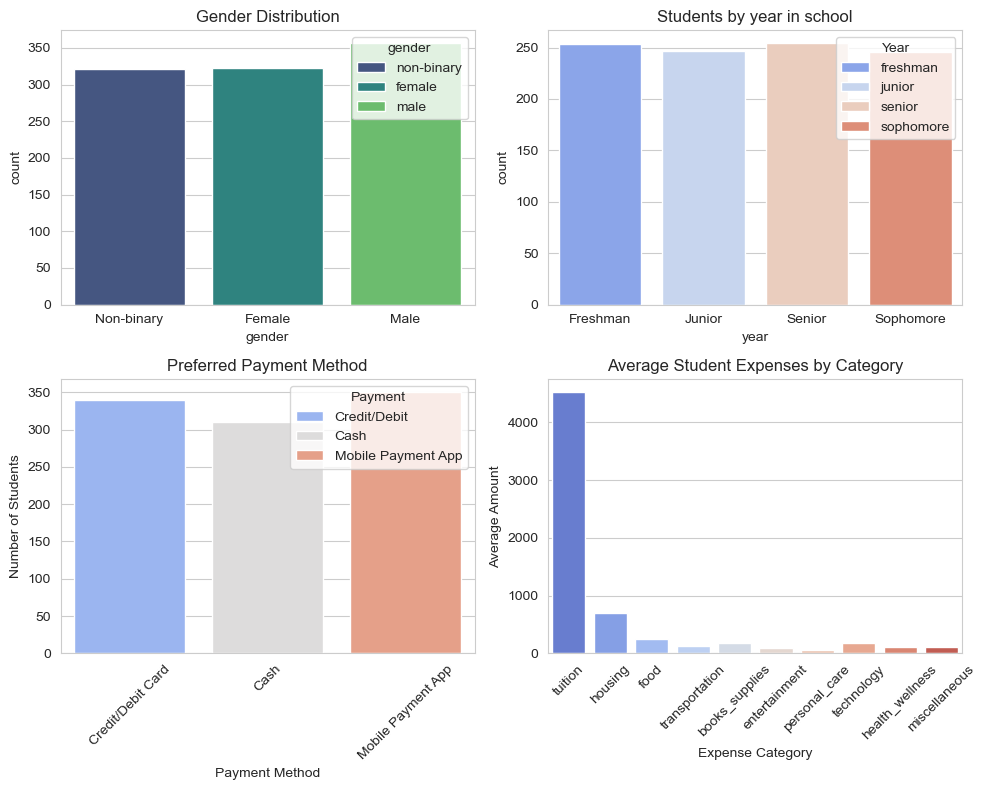

In [70]:
# Bar chart

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
sns.countplot(data=df, x='gender', hue="gender", palette='viridis')
plt.title("Gender Distribution")
plt.xlabel("gender")
plt.ylabel("count")
plt.legend(title='gender',labels=['non-binary','female','male'])


plt.subplot(2,2,2)
sns.countplot(data=df, x='year_in_school', hue="year_in_school",palette='coolwarm')
plt.title("Students by year in school")
plt.xlabel("year")
plt.ylabel("count")
plt.legend(title='Year',labels=['freshman','junior','senior', 'sophomore'])

plt.subplot(2,2,3)
sns.countplot(x='preferred_payment_method', data=df, hue="preferred_payment_method",palette='coolwarm')
plt.title("Preferred Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.legend(title='Payment',labels=['Credit/Debit','Cash','Mobile Payment App'])

plt.subplot(2,2,4)
expenses = ['tuition','housing','food','transportation',
            'books_supplies','entertainment','personal_care',
            'technology','health_wellness','miscellaneous']
# Calculate mean expenses
expense_mean = df[expenses].mean().reset_index()
expense_mean.columns = ['Expense Category', 'Average Amount']

sns.barplot(x='Expense Category', y='Average Amount', data=expense_mean, hue='Expense Category', palette='coolwarm')
plt.title("Average Student Expenses by Category")
plt.xlabel("Expense Category")
plt.ylabel("Average Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

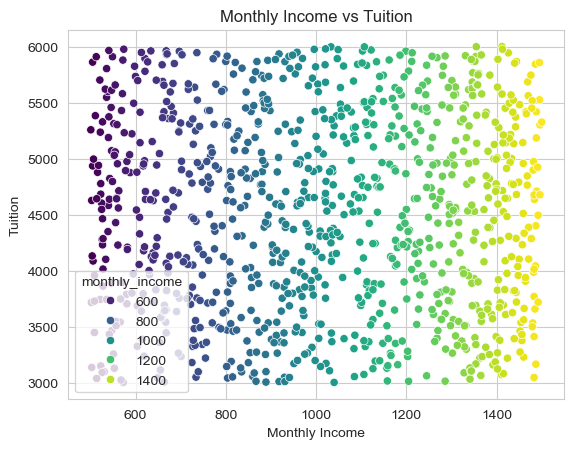

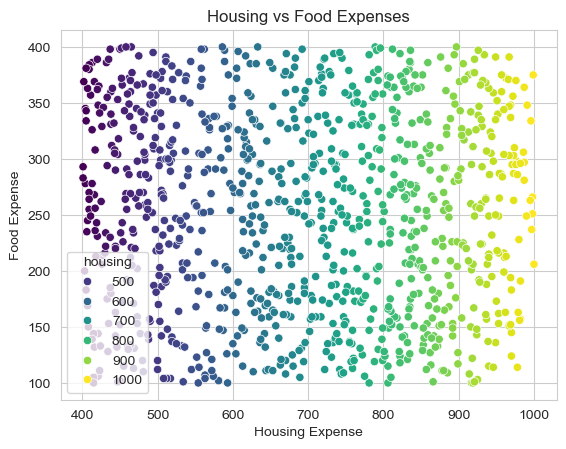

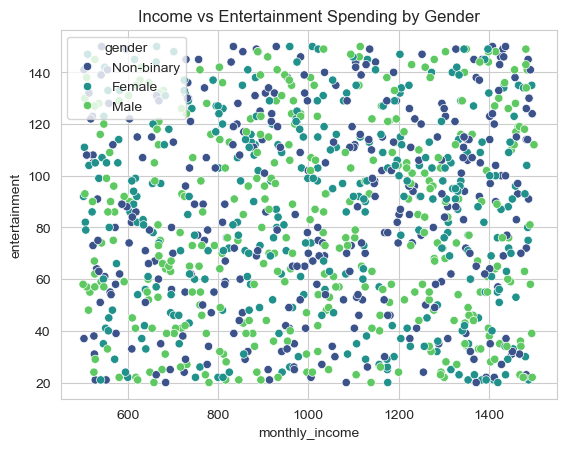

In [84]:
# Scatter plot


sns.scatterplot(x='monthly_income', y='tuition', data=df, hue='monthly_income', palette='viridis')

plt.title("Monthly Income vs Tuition")
plt.xlabel("Monthly Income")
plt.ylabel("Tuition")
plt.show()

sns.scatterplot(x='housing', y='food', data=df, hue='housing', palette='viridis')

plt.title("Housing vs Food Expenses")
plt.xlabel("Housing Expense")
plt.ylabel("Food Expense")
plt.show()

sns.scatterplot(x='monthly_income', y='entertainment', hue='gender', data=df, palette='viridis')

plt.title("Income vs Entertainment Spending by Gender")
plt.show()


C:\Users\AITSYNERGY-RAKSHITHA\AppData\Local\Temp\ipykernel_47396\3910866871.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='monthly_income', data=df, palette='viridis')


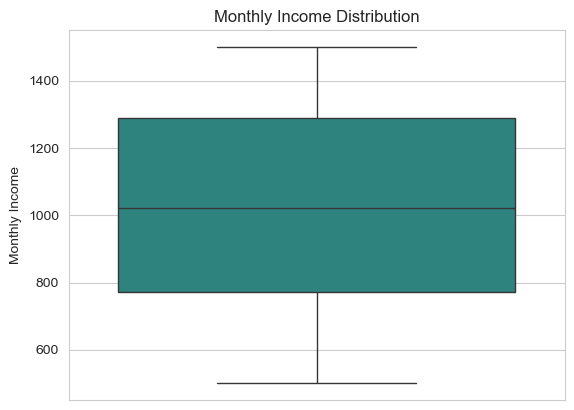

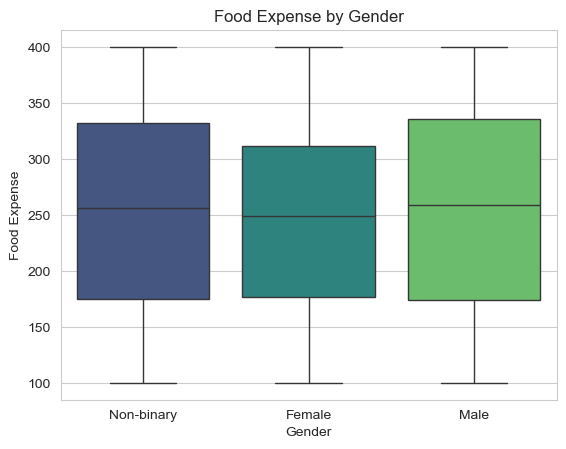

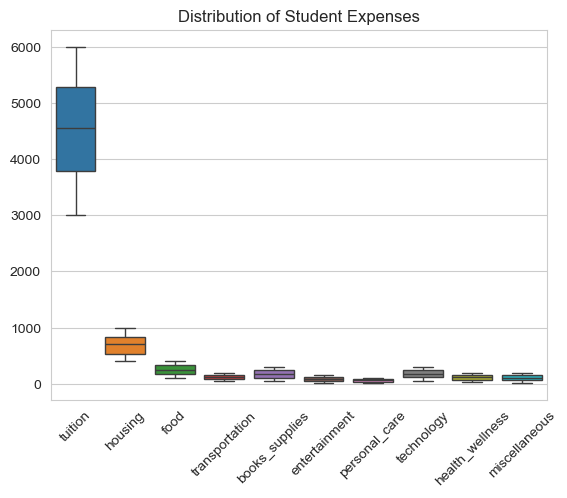

In [108]:
# Box Plot

sns.boxplot(y='monthly_income', data=df, palette='viridis')

plt.title("Monthly Income Distribution")
plt.ylabel("Monthly Income")
plt.show()

sns.boxplot(x='gender', y='food', data=df, hue='gender', palette='viridis')

plt.title("Food Expense by Gender")
plt.xlabel("Gender")
plt.ylabel("Food Expense")
plt.show()

expenses = ['tuition','housing','food','transportation',
            'books_supplies','entertainment','personal_care',
            'technology','health_wellness','miscellaneous']

sns.boxplot(data=df[expenses])

plt.title("Distribution of Student Expenses")
plt.xticks(rotation=45)
plt.show()

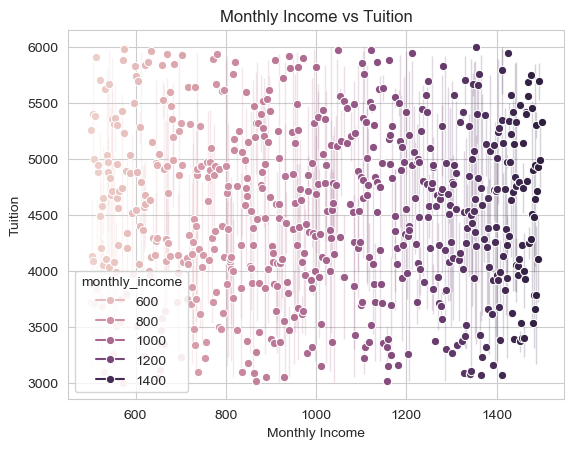

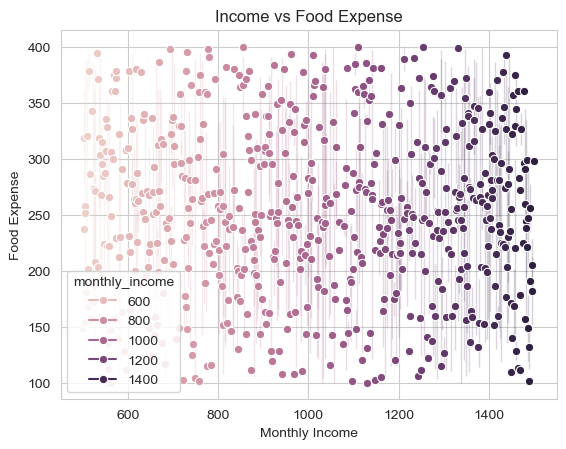

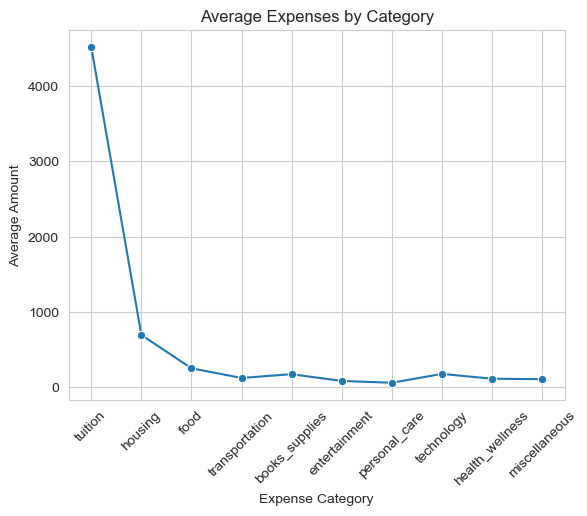

In [109]:
# Line chart

sns.lineplot(x='monthly_income', y='tuition', data=df, hue='monthly_income', marker='o')

plt.title("Monthly Income vs Tuition")
plt.xlabel("Monthly Income")
plt.ylabel("Tuition")
plt.show()

sns.lineplot(x='monthly_income', y='food', data=df,hue='monthly_income', marker='o')

plt.title("Income vs Food Expense")
plt.xlabel("Monthly Income")
plt.ylabel("Food Expense")
plt.show()

expenses = ['tuition','housing','food','transportation',
            'books_supplies','entertainment','personal_care',
            'technology','health_wellness','miscellaneous']

avg_expense = df[expenses].mean()

sns.lineplot(x=avg_expense.index, y=avg_expense.values, marker='o')

plt.title("Average Expenses by Category")
plt.xlabel("Expense Category")
plt.ylabel("Average Amount")
plt.xticks(rotation=45)
plt.show()

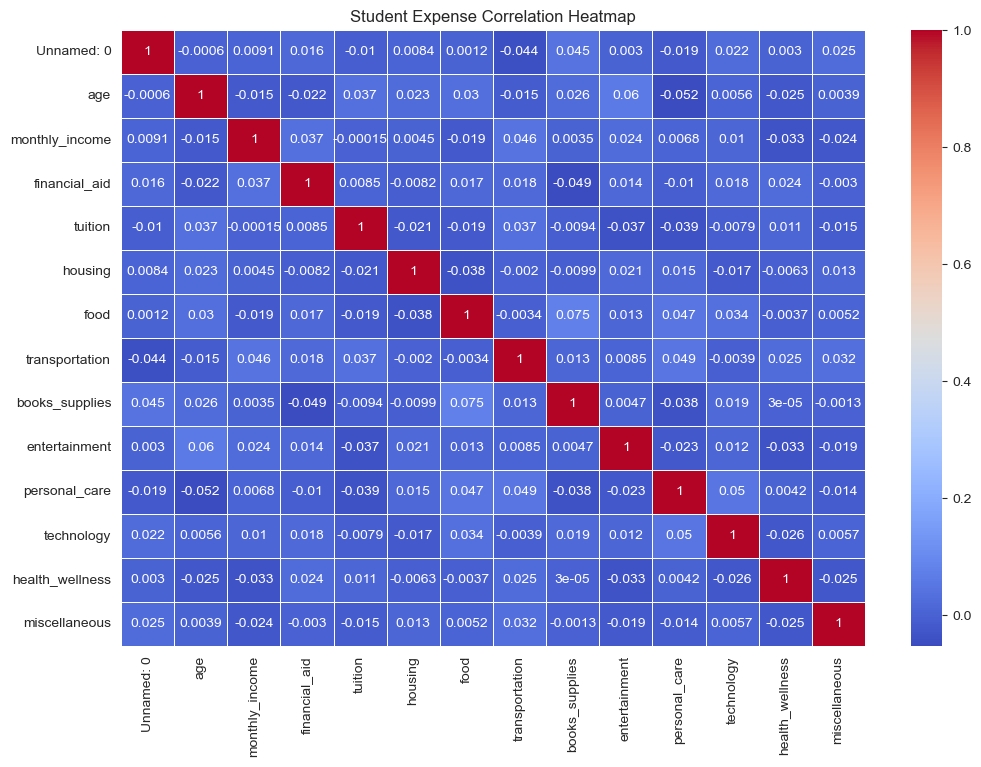

In [106]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Student Expense Correlation Heatmap")
plt.show()